# `rvcadence` quickstart demo

An elaborated, runnable version of the examples in the README, with visual
outputs. Covers:

1. Basic scheduling from hand-typed windows
2. Multi-planet phase coverage (worst-case aggregation)
3. Astropy-based visibility — resolving a target/site by name
4. Composable constraints (windows ∩ moon ∩ visibility)
5. A calendar view of the final schedule
6. Two bonus diagnostics: altitude-threshold sensitivity, and greedy vs. random phase coverage

Requires `pip install rvcadence[astro]` plus `matplotlib` for this notebook
(not a package dependency, just needed to run these cells).

In [23]:
from datetime import date, timedelta

import matplotlib.pyplot as plt
import numpy as np

from rvcadence import (
    is_visible,
    plan_calendar,
    resolve_site_name,
    resolve_target_name,
    target_transit_time,
    visibility_allowed_offsets,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 1. Basic quickstart — hand-typed windows

Straight from the README: schedule 20 observations of a 9.53 d planet across
two visibility windows, phased against a 12.45 d stellar rotation period.

In [24]:
season_start = date(2026, 5, 1)
season_end = date(2027, 4, 30)
period_d = 9.53
p_rot_d = 12.45

result = plan_calendar(
    n_obs=20,
    periods_d=period_d,
    season_start=season_start,
    season_end=season_end,
    rotation_period_d=p_rot_d,
    windows="2026-05-01 to 2026-05-19; 2026-07-29 to 2027-04-30",
)

print(f"{len(result.dates)} dates scheduled")
print(f"median gap: {result.median_gap_d} d, mean gap: {result.mean_gap_d} d")
result.dates


20 dates scheduled
median gap: 14.0 d, mean gap: 19.157894736842106 d


[datetime.date(2026, 5, 1),
 datetime.date(2026, 5, 10),
 datetime.date(2026, 8, 7),
 datetime.date(2026, 8, 28),
 datetime.date(2026, 8, 29),
 datetime.date(2026, 9, 7),
 datetime.date(2026, 9, 10),
 datetime.date(2026, 9, 28),
 datetime.date(2026, 10, 9),
 datetime.date(2026, 10, 26),
 datetime.date(2026, 11, 10),
 datetime.date(2026, 12, 29),
 datetime.date(2027, 1, 7),
 datetime.date(2027, 1, 27),
 datetime.date(2027, 2, 9),
 datetime.date(2027, 3, 8),
 datetime.date(2027, 3, 22),
 datetime.date(2027, 3, 31),
 datetime.date(2027, 4, 1),
 datetime.date(2027, 4, 30)]

### Visualizing the schedule

Two views of the same result: a **timeline** (where in the season the
observations fall, relative to the requested windows) and a **phase-coverage**
plot (where the planet's orbital phase and the stellar-rotation phase land at
each chosen date — the two should spread out fairly evenly if the greedy
algorithm is doing its job).

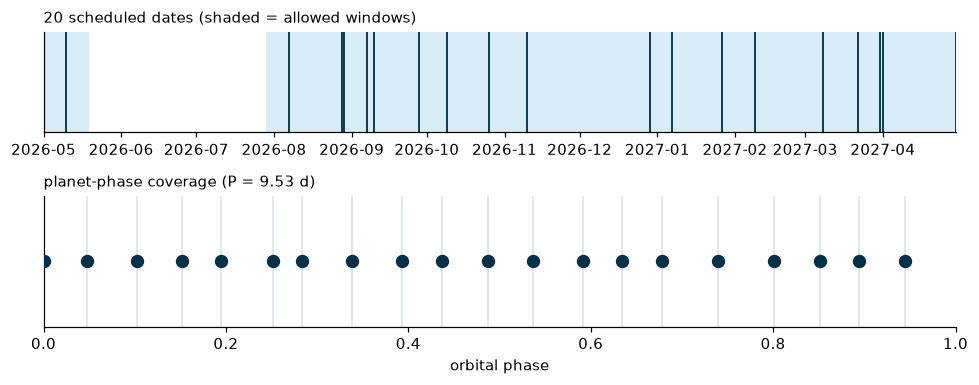

In [25]:
def plot_timeline(ax, dates, season_start, season_end, windows=None, label=""):
    ax.set_xlim(season_start, season_end)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    if windows:
        for w_start, w_end in windows:
            ax.axvspan(w_start, w_end, color="#8ecae6", alpha=0.35, lw=0)
    ax.vlines(dates, 0, 1, color="#023047", lw=1.2)
    ax.set_title(label, loc="left", fontsize=10)


def plot_phase_coverage(ax, dates, period_d, ref_date, label="", color="#023047"):
    phases = [((d - ref_date).days % period_d) / period_d for d in dates]
    ax.scatter(phases, np.zeros_like(phases), s=60, color=color, zorder=3)
    for p in phases:
        ax.axvline(p, color=color, alpha=0.15, lw=1)
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("orbital phase")
    ax.set_title(label, loc="left", fontsize=10)


windows = [(date(2026, 5, 1), date(2026, 5, 19)), (date(2026, 7, 29), date(2027, 4, 30))]

fig, axes = plt.subplots(2, 1, figsize=(9, 3.6), gridspec_kw={"height_ratios": [1, 1.3]})
plot_timeline(axes[0], result.dates, season_start, season_end, windows,
              label=f"{len(result.dates)} scheduled dates (shaded = allowed windows)")
plot_phase_coverage(axes[1], result.dates, period_d, season_start,
                     label=f"planet-phase coverage (P = {period_d} d)")
fig.tight_layout()
plt.show()


## 2. Multi-planet phase coverage

For a two-planet system, `periods_d` takes a list. Coverage at each greedy
step is optimized for the **worst-covered** planet, not an average — so one
well-phased planet can't hide a poorly-phased one. We can see this directly
by phase-folding the *same* schedule against both periods.

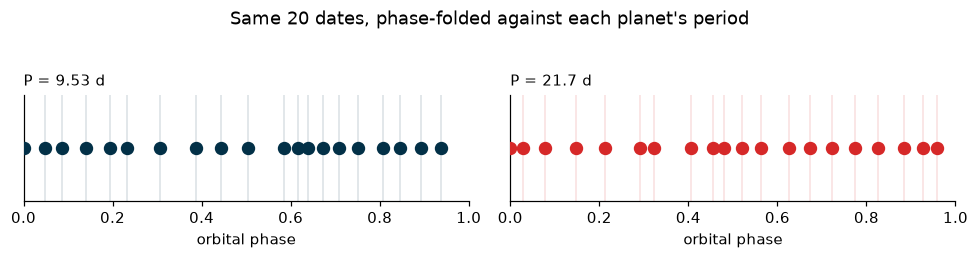

median gap: 15.0 d, mean gap: 19.157894736842106 d


In [26]:
periods_multi = [9.53, 21.7]

result_multi = plan_calendar(
    n_obs=20,
    periods_d=periods_multi,
    season_start=season_start,
    season_end=season_end,
)

fig, axes = plt.subplots(1, 2, figsize=(9, 2.2))
for ax, p, color in zip(axes, periods_multi, ["#023047", "#d62828"]):
    plot_phase_coverage(ax, result_multi.dates, p, season_start,
                         label=f"P = {p} d", color=color)
fig.suptitle("Same 20 dates, phase-folded against each planet's period", y=1.05)
fig.tight_layout()
plt.show()

print(f"median gap: {result_multi.median_gap_d} d, mean gap: {result_multi.mean_gap_d} d")


## 3. Astropy-based visibility — resolve a target and site by name

No more hand-typing visibility windows: give `rvcadence` a target name and an
observatory name, and it resolves both (printing the resolved coordinates for
confirmation) and computes visibility itself — a target is "visible" on a
given night if there is *any* instant when it clears `min_altitude_deg` while
the Sun is below `twilight_sun_alt_deg`, sampled across the full night.

In [27]:
target_coord = resolve_target_name("K2-182")
observer_location = resolve_site_name("Paranal Observatory")


Resolved target 'K2-182' to 08h40m43.2795984s +10d58m58.599516s (ICRS)
Resolved site 'Paranal Observatory' to lat=-24.6274, lon=-70.4050, height=2669 m


### A night-by-night airmass ("staralt") chart

For a *fixed* target and site, the altitude reached at true transit is
geometrically constant (`90 deg - |lat - dec|`) — it does not vary with the
season. What varies is *when in the night* transit happens, and therefore
whether it falls in daylight, twilight, or full darkness. A single
"altitude at transit" number per night is therefore a flat line and not
useful; the informative view is airmass as a function of both night and
time-of-night, masked to when it's actually usable (dark, and Moon far
enough away) — the classic "staralt" chart. Color = airmass (lower =
better); masked (white) wherever it's daylight, the target is below the
horizon, or the Moon is within `min_moon_sep_deg` that night (moon
separation is evaluated once per night, at local midnight — the same
convention `plan_calendar()`/`moon_allowed_offsets()` use).


/tmp/ipykernel_701461/2211712346.py:38: RuntimeWarning: All-NaN slice encountered
  peak_observable_alt = np.nanmax(observable_alt, axis=1)  # nan on nights with no usable window at all
/tmp/ipykernel_701461/2211712346.py:39: RuntimeWarning: All-NaN slice encountered
  best_airmass_per_night = np.nanmin(airmass_grid, axis=1)  # lowest airmass = best, per night


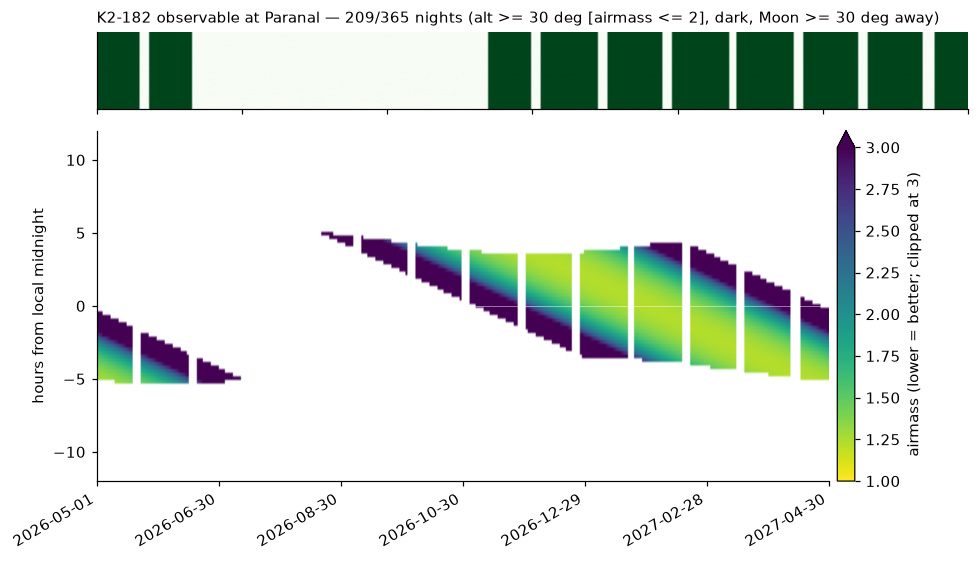

Lowest achievable airmass this season: 1.23 around 2027-03-21


In [28]:
import warnings

import astropy.units as u
from astropy.coordinates import AltAz, get_sun
from astropy.coordinates.errors import NonRotationTransformationWarning
from rvcadence.moon import _local_midnight_utc, is_moon_polluted

n_days = (season_end - season_start).days + 1
nights = [season_start + timedelta(days=k) for k in range(n_days)]
offsets_min = np.linspace(-12 * 60, 12 * 60, 2 * 12 * 60 // 15 + 1)  # same grid is_visible() uses

alt_grid = np.full((n_days, len(offsets_min)), np.nan)
dark_grid = np.zeros((n_days, len(offsets_min)), dtype=bool)
moon_ok = np.zeros(n_days, dtype=bool)

with warnings.catch_warnings():
    # Expected/accepted caveat noted during v0.2 review (group-meeting [S1]):
    # separations between a time-dependent frame (Moon, GCRS) and ICRS aren't
    # strictly rotation-only. Doesn't affect correctness here, just noisy.
    warnings.simplefilter("ignore", NonRotationTransformationWarning)
    for i, night in enumerate(nights):
        t_mid = _local_midnight_utc(night, observer_location)
        times = t_mid + offsets_min * u.minute
        frame = AltAz(obstime=times, location=observer_location)
        alt_grid[i] = target_coord.transform_to(frame).alt.deg
        dark_grid[i] = get_sun(times).transform_to(frame).alt.deg <= -18.0
        moon_ok[i] = not is_moon_polluted(night, target_coord, observer_location, min_sep_deg=30.0)

# Altitude where it's actually usable: dark AND Moon far enough that whole
# night (moon check is per-night, not per-sample -- matches plan_calendar()).
observable_alt = np.where(dark_grid & moon_ok[:, None], alt_grid, np.nan)

# Airmass (plane-parallel secant approximation) -- undefined/meaningless at or
# below the horizon, so mask those out rather than let them blow up the scale.
with np.errstate(invalid="ignore", divide="ignore"):
    airmass_grid = 1.0 / np.sin(np.radians(np.where(observable_alt > 0, observable_alt, np.nan)))

peak_observable_alt = np.nanmax(observable_alt, axis=1)  # nan on nights with no usable window at all
best_airmass_per_night = np.nanmin(airmass_grid, axis=1)  # lowest airmass = best, per night
is_observable = np.nan_to_num(peak_observable_alt, nan=-90.0) >= 30.0

fig, (ax_strip, ax_heat) = plt.subplots(
    2, 1, figsize=(9, 5.2), sharex=True, gridspec_kw={"height_ratios": [0.22, 1]}
)

ax_strip.imshow(is_observable.astype(float).reshape(1, -1), aspect="auto", cmap="Greens",
                 vmin=0, vmax=1, extent=[0, n_days, 0, 1])
ax_strip.set_yticks([])
ax_strip.set_title(
    f"K2-182 observable at Paranal — {int(is_observable.sum())}/{n_days} nights "
    f"(alt >= 30 deg [airmass <= 2], dark, Moon >= 30 deg away)",
    loc="left", fontsize=10,
)

hour_offsets = offsets_min / 60.0
im = ax_heat.imshow(
    np.ma.masked_invalid(airmass_grid.T), aspect="auto", origin="lower", cmap="viridis_r",
    vmin=1.0, vmax=3.0, extent=[0, n_days, hour_offsets.min(), hour_offsets.max()],
)
ax_heat.axhline(0, color="white", lw=0.6, alpha=0.5)
cbar = fig.colorbar(im, ax=ax_heat, pad=0.01, extend="max")
cbar.set_label("airmass (lower = better; clipped at 3)")
ax_heat.set_ylabel("hours from local midnight")
ax_heat.set_xticks(np.linspace(0, n_days, 7))
ax_heat.set_xticklabels(
    [(season_start + timedelta(days=int(d))).isoformat() for d in np.linspace(0, n_days - 1, 7)],
    rotation=30, ha="right",
)
fig.tight_layout()
plt.show()

best_idx = int(np.nanargmin(best_airmass_per_night))
print(f"Lowest achievable airmass this season: {best_airmass_per_night[best_idx]:.2f} "
      f"around {nights[best_idx]}")


The bright band tracks the target's best achievable airmass night by night:
it sits near its floor (~1.24, the geometric best for this target/site pair)
for most of the season, then worsens and narrows as transit shifts
later/earlier relative to the dark window near conjunction with the Sun —
that patch (and the recurring vertical white gaps from lunar avoidance) is
exactly what drives the gaps in the green strip above it. This is the same
quantity `is_visible()` checks (altitude + twilight, sampled across the full
night), now with lunar avoidance folded into the same "observable"
definition and expressed as airmass instead of raw altitude.


## 4. Final calendar view

The full picture: which nights survive every constraint, and which of those
the greedy scheduler actually picked.

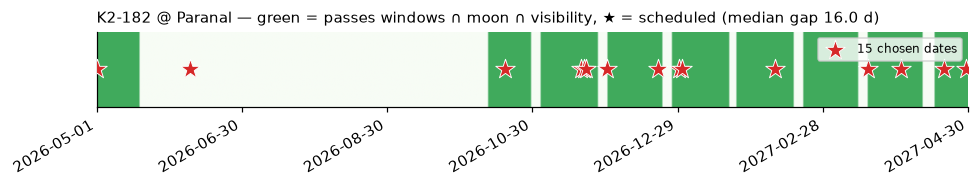

In [29]:
final = plan_calendar(
    n_obs=15,
    periods_d=period_d,
    season_start=season_start,
    season_end=season_end,
    rotation_period_d=p_rot_d,
    target_coord=target_coord,
    observer_location=observer_location,
    min_moon_sep_deg=30.0,
    min_altitude_deg=30.0,
)

allowed_all = sorted(windows_allowed & moon_allowed & vis_allowed)
allowed_mask = np.zeros(n_days, dtype=bool)
allowed_mask[allowed_all] = True

fig, ax = plt.subplots(figsize=(9, 1.8))
ax.imshow(allowed_mask.astype(float).reshape(1, -1), aspect="auto", cmap="Greens",
          vmin=0, vmax=1.6, extent=[0, n_days, 0, 1])
chosen_idx = [(d - season_start).days for d in final.dates]
ax.scatter(chosen_idx, np.full(len(chosen_idx), 0.5), marker="*", s=180,
           color="#d62828", edgecolor="white", linewidth=0.6, zorder=3,
           label=f"{len(final.dates)} chosen dates")
ax.set_yticks([])
ax.set_xticks(np.linspace(0, n_days, 7))
ax.set_xticklabels(
    [(season_start + timedelta(days=int(d))).isoformat() for d in np.linspace(0, n_days - 1, 7)],
    rotation=30, ha="right",
)
ax.set_title(
    f"K2-182 @ Paranal — green = passes windows ∩ moon ∩ visibility, "
    f"★ = scheduled (median gap {final.median_gap_d} d)",
    loc="left", fontsize=10,
)
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


## Bonus 1 — how sensitive is the cadence to the altitude threshold?

`min_altitude_deg=30°` (≈airmass 2 at Paranal) is a common round-number
default, but it's worth seeing how much it actually costs versus a looser or
stricter cut before committing to it for a real campaign.

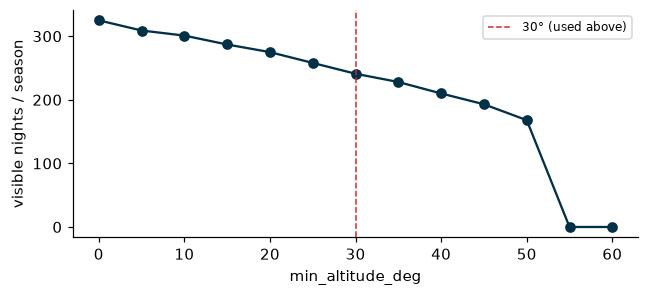

In [30]:
thresholds = np.arange(0, 61, 5)
n_visible_nights = [
    len(visibility_allowed_offsets(season_start, season_end, target_coord, observer_location,
                                    min_altitude_deg=float(thr)))
    for thr in thresholds
]

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot(thresholds, n_visible_nights, marker="o", color="#023047")
ax.axvline(30.0, color="#d62828", ls="--", lw=1, label="30° (used above)")
ax.set_xlabel("min_altitude_deg")
ax.set_ylabel("visible nights / season")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Bonus 2 — does the greedy algorithm actually beat random dates?

A sanity check on the core claim: phase coverage from `plan_calendar`'s
greedy selection should be much more uniform than picking the same number of
dates at random from the same allowed nights.

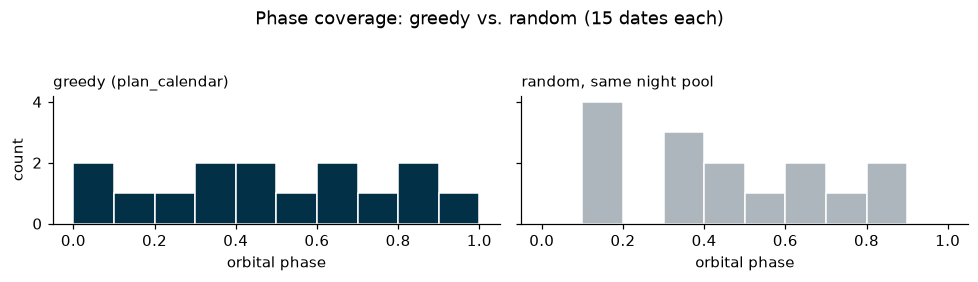

In [31]:
rng = np.random.default_rng(42)
random_idx = rng.choice(sorted(allowed_all), size=len(final.dates), replace=False)
random_dates = [season_start + timedelta(days=int(k)) for k in random_idx]

fig, axes = plt.subplots(1, 2, figsize=(9, 2.4), sharey=True)
for ax, dates, label, color in zip(
    axes, [final.dates, random_dates], ["greedy (plan_calendar)", "random, same night pool"],
    ["#023047", "#adb5bd"],
):
    phases = [((d - season_start).days % period_d) / period_d for d in dates]
    ax.hist(phases, bins=10, range=(0, 1), color=color, edgecolor="white")
    ax.set_xlabel("orbital phase")
    ax.set_title(label, loc="left", fontsize=10)
axes[0].set_ylabel("count")
fig.suptitle(f"Phase coverage: greedy vs. random ({len(final.dates)} dates each)", y=1.05)
fig.tight_layout()
plt.show()
